# Project 2 — Exploratory Data Analysis
## CDC Disability and Health Data System (DHDS)

**Name:** Dionne Dyson
**Course:** Python Software Development and Data Analytics
**Due:** September 10 (super late, but will make next projects EARLY!)
**Data source:** CDC Disability and Health Data System (DHDS), data.cdc.gov

---

### How this notebook works

This is a **scaffold**. Cells marked **`# YOUR TURN`** are yours to write.
Hints tell you *which tool* to reach for — not the finished line.

If you get stuck for more than 10 minutes on one cell, bring it to me and we
debug it together. Stuck-then-unstuck is how it sticks. Copying is not.

### Requirements checklist

- [ ] Load and clean a government dataset
- [ ] `groupby`
- [ ] `crosstab`
- [ ] Charts (Lecture 16)
- [ ] A written story around the finding

---

My research question

**Research Question:** Among women 50–74, does mammogram screening differ between those with and without a disability?

More specifically, are women aged 50–74 with disabilities less likely to have had a mammogram in the past two years compared to women without disabilities? Is that gap even wider for women who are classified as deaf or hard of hearing?

**Why it matters:** Breast cancer screening saves lives, but only when women actually get screened. Women with disabilities already face various barriers to healthcare access. If Deaf and hard-of-hearing women are falling further behind, that points to a specific gap: communication barriers, lack of provider training, and lower health literacy. Lower rates of mammogram screening signal a major health disparity that leads to delayed diagnosis and increased risk of mortality.

## 1. Setup and load 📂

In [36]:
import pandas as pd  # pandas is for data analysis
import numpy as np   # numpy is for math & computation
import matplotlib.pyplot as plt  #matplotlib is charts

# show charts inside the notebook
%matplotlib inline                       
pd.set_option('display.max_columns', 40)   # don't hide columns
pd.set_option('display.width', 200)        # don't wrap rows
 


In [37]:
FILE = "D:/Python Data/Disability_and_Health_Data_System_(DHDS)_20260902.csv"
df = pd.read_csv(FILE, low_memory=False)

---
## 2. First look

Run these, then **write what you see** in the markdown cell below. Don't skip
the writing — graders read interpretation, not output.

In [3]:
import os
print(os.listdir("D:/Python Data"))

FILE="D:/Python Data/Disability_and_Health_Data_System_(DHDS)_20260902.csv" #creates variable named FILE and store it as such (FILE)

df=pd.read_csv(FILE) #open CSV file at that path, turn into table, call the table df
df.shape #displays rows & columns


['DHDS_FirstLook.ipynb', 'DHDS_Practice_Gym_Lec11to17.ipynb', 'Disability_and_Health_Data_System_(DHDS)_20260902.csv', 'Project_2_WORKING.ipynb']


C:\Users\dionn\AppData\Local\Temp\ipykernel_14260\3013647856.py:6: DtypeWarning: Columns (0,24) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv(FILE) #open CSV file at that path, turn into table, call the table df


(751072, 32)

In [4]:
df=pd.read_csv(FILE, low_memory=False) #open CSV file at that path, turn into table, call the table "df" and ignore mixed types
df.shape

(751072, 32)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 751072 entries, 0 to 751071
Data columns (total 32 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Rowid                       621902 non-null  object 
 1   Year                        751072 non-null  int64  
 2   LocationAbbr                751072 non-null  object 
 3   LocationDesc                751072 non-null  object 
 4   DataSource                  751072 non-null  object 
 5   Category                    751072 non-null  object 
 6   Indicator                   751072 non-null  object 
 7   Response                    740296 non-null  object 
 8   Data_Value_Unit             751072 non-null  object 
 9   Data_Value_Type             751072 non-null  object 
 10  Data_Value                  674653 non-null  float64
 11  Data_Value_Alt              674653 non-null  float64
 12  Data_Value_Footnote_Symbol  76419 non-null   object 
 13  Data_Value_Foo

In [6]:
df.head()

,Rowid,Year,LocationAbbr,LocationDesc,DataSource,Category,Indicator,Response,Data_Value_Unit,Data_Value_Type,Data_Value,Data_Value_Alt,Data_Value_Footnote_Symbol,Data_Value_Footnote,Low_Confidence_Limit,High_Confidence_Limit,Number,WeightedNumber,StratificationCategory1,Stratification1,StratificationCategory2,Stratification2,CategoryID,IndicatorID,Geolocation,LocationID,ResponseID,DataValueTypeID,StratificationCategoryID1,StratificationID1,StratificationCategoryID2,StratificationID2
0,2555,2021,HHS8,HHS Region 8,BRFSS,Disability Estimates,Disability status and types among adults 18 ye...,Female,%,Age-adjusted Prevalence,13.7,13.7,NaN,NaN,13.0,14.5,"2,555","606,311",Disability Type,Cognitive Disability,NaN,NaN,DISEST,SEXIND,NaN,87,SEX02,AGEADJPREV,DISTYPE,COGDIS,NaN,NaN
1,857,2021,HHS7,HHS Region 7,BRFSS,Disability Estimates,Disability status and types among adults 18 ye...,Male,%,Age-adjusted Prevalence,3.0,3.0,NaN,NaN,2.6,3.4,857,"166,227",Disability Type,Self-care Disability,NaN,NaN,DISEST,SEXIND,NaN,86,SEX01,AGEADJPREV,DISTYPE,SELFDIS,NaN,NaN
2,NaN,2021,MI,Michigan,BRFSS,Disability Estimates,Disability status and types among adults 18 ye...,"Asian, non-Hispanic",%,Age-adjusted Prevalence,NaN,NaN,*,Data suppressed,NaN,NaN,NaN,NaN,Disability Status,Any Disability,NaN,NaN,DISEST,RACEIND,POINT (-84.71439026999968 44.6613195430005),26,RACE05,AGEADJPREV,DISSTAT,DISABL,NaN,NaN
3,105,2021,HHS3,HHS Region 3,BRFSS,Disability Estimates,Disability status and types among adults 18 ye...,Hispanic,%,Age-adjusted Prevalence,4.7,4.7,NaN,NaN,3.2,6.9,105,"79,451",Disability Type,Hearing Disability,NaN,NaN,DISEST,RACEIND,NaN,82,RACE03,AGEADJPREV,DISTYPE,HEARDIS,NaN,NaN
4,NaN,2021,HHS8,HHS Region 8,BRFSS,Disability Estimates,Disability status and types among adults 18 ye...,"Asian, non-Hispanic",%,Age-adjusted Prevalence,NaN,NaN,*,Data suppressed,NaN,NaN,NaN,NaN,Disability Type,Hearing Disability,NaN,NaN,DISEST,RACEIND,NaN,87,RACE05,AGEADJPREV,DISTYPE,HEARDIS,NaN,NaN


In [38]:
df['Year'].unique() #prints every value in the Year column

array([2021, 2019, 2020, 2016, 2018, 2017, 2022])

In [39]:
sorted(df['Year'].unique()) #sorted() wraps around the result-ascended order

[np.int64(2016),
 np.int64(2017),
 np.int64(2018),
 np.int64(2019),
 np.int64(2020),
 np.int64(2021),
 np.int64(2022)]

In [9]:
sorted(df['Year'].unique(), reverse=True) #flips to descending order

[np.int64(2022),
 np.int64(2021),
 np.int64(2020),
 np.int64(2019),
 np.int64(2018),
 np.int64(2017),
 np.int64(2016)]

What I found in the first look:

1. Rows / columns: 751,072 rows and 32 columns
2. Years covered: 2016-2022
3. Shape of the data (long vs wide) — and what that means: long format- one fact about one grop in one state in one year
4. Columns I'll actually use: Indicator, Response, Stratification1, Data_value, LocationDesc, Year
5. Anything that looks messy: Two columns have mixed type of data, and df.info() showed some columns with missing values  
   

## 3. Clean the data 

Three cleaning jobs, in order.

### 3a. Narrow to your question

You cannot analyze 750,000 rows of mixed questions at once. Filter down to
**one indicator, one response, one year.**

💡 **Hint:** boolean masks joined with `&`, each condition in its own `( )`.
To find the exact indicator text, run `df['Indicator'].unique()` first.

In [10]:
# Find the exact text of the indicator you want
df[df['Indicator'].str.contains('Mammogram', na=False)]['Indicator'].unique() 

#pull the indicator column with text string (.str), look inside each cell return True if the word Mammogram is found, 
# False if it doesn't. '.strcontaints()' - answer only True or False
#find every row where the indicator column contains the word Mammogram, then show the unique indicator names


array(['Mammogram in the past 2 years among females 50 to 74 years of age'],
      dtype=object)

In [11]:
#filter to mammogram indicator, Yes response, disability status only

# keep only the mammogram question
# (df['Indicator'] == 'Mammogram in the past 2 years among females 50 to 74 years of age')

# keep only women who said Yes (they got one)
# & (df['Response'] == 'Yes')

# keep only the disability status comparison rows
# & (df['StratificationCategory1'] == 'Disability Status')

# exclude rows that have a second stratifier (age, race, sex breakouts)
# & (df['StratificationCategory2'].isna())

mammo = df[
        (['Indicator'] == 'Mammogram in the past 2 years among females 50 to 74 years of age') & (df['Response'] == 'Yes')
        & (df['Response'] == 'Yes')
        & (df['StratificationCategory1'] == 'Disability Status')
        & (df['StratificationCategory2'].isna())
    ]
mammo.shape




(0, 32)

In [12]:
print(df['Response'].unique())

['Female' 'Male' 'Asian, non-Hispanic' 'Hispanic' 'Veteran'
 'Some High School or Less' 'College Graduate' 'Widowed' 'Never Married'
 '$50,000+' '$35,000 to <$50,000' '<$15,000' 'Employed' 'Out of Work'
 'Unable to Work' 'No' 'Yes' 'Underweight' 'Overweight' 'Normal Weight'
 'Obese' 'Current Smoker' 'Former Smoker' 'Never Smoker' nan '1-13 Days'
 '0 Days' '14+ Days' '45-64' '65+' 'No Disability'
 'Other / Multirace, non-Hispanic' 'Black, non-Hispanic' 'Non-Veteran'
 'Divorced / Separated' '$25,000 to <$35,000' 'High School Graduate'
 '$15,000 to <$25,000' 'American Indian or Alaska Native, non-Hispanic'
 '18-44' 'Native Hawaiian or Other Pacific Islander, non-Hispanic' 'Other'
 'White, non-Hispanic' 'Mobility Disability' 'Hearing Disability'
 'Married / Unmarried Couple' 'Independent Living Disability'
 'Vision Disability' 'Any Disability' 'Self-care Disability'
 'Cognitive Disability' '1 Provider' '2+ Providers' '1-6 Hours'
 '10+ Hours' '7-9 Hours' 'Meets Muscle Strengthening Only' 'M

In [13]:
print(df['StratificationCategory1'].unique())

['Disability Type' 'Disability Status' 'Overall']


In [14]:
print(df['Stratification1'].unique())

['Cognitive Disability' 'Self-care Disability' 'Any Disability'
 'Hearing Disability' 'Mobility Disability'
 'Independent Living Disability' 'No Disability' 'Vision Disability'
 'Overall']


In [15]:
print(list(df.columns))

['Rowid', 'Year', 'LocationAbbr', 'LocationDesc', 'DataSource', 'Category', 'Indicator', 'Response', 'Data_Value_Unit', 'Data_Value_Type', 'Data_Value', 'Data_Value_Alt', 'Data_Value_Footnote_Symbol', 'Data_Value_Footnote', 'Low_Confidence_Limit', 'High_Confidence_Limit', 'Number', 'WeightedNumber', 'StratificationCategory1', 'Stratification1', 'StratificationCategory2', 'Stratification2', 'CategoryID', 'IndicatorID', 'Geolocation', 'LocationID', 'ResponseID', 'DataValueTypeID', 'StratificationCategoryID1', 'StratificationID1', 'StratificationCategoryID2', 'StratificationID2']


In [16]:
df[df['Indicator'] == 'Mammogram in the past 2 years among females 50 to 74 years of age'].shape
#how many rows where the Indicator says exactly the string

(7224, 32)

In [17]:
df[(df['Indicator'] == 'Mammogram in the past 2 years among females 50 to 74 years of age')
& (df['Response'] == 'Yes')].shape

(3612, 32)

In [18]:
df[(df['Indicator'] == 'Mammogram in the past 2 years among females 50 to 74 years of age')
    & (df['Response'] == 'Yes')
    & (df['StratificationCategory1'] == 'Disability Status')
].shape

(2580, 32)

In [19]:
df[(df['Indicator'] == 'Mammogram in the past 2 years among females 50 to 74 years of age')
    & (df['Response'] == 'Yes')
    & (df['StratificationCategory1'] == 'Disability Status')
    & (df['StratificationCategory2'].isna())].shape

(516, 32)

In [20]:
df[(df['Indicator'] == 'Mammogram in the past 2 years among females 50 to 74 years of age')
    & (df['Response'] == 'Yes')
    & (df['StratificationCategory1'] == 'Disability Status')
    & (df['StratificationCategory2'].isna())]

mammo.shape

(0, 32)

In [21]:
mammo = df[(df['Indicator'] == 'Mammogram in the past 2 years among females 50 to 74 years of age')
# create a new table called mammo, filtered from df

    & (df['Response'] == 'Yes')
# keep only rows about the mammogram question

    & (df['StratificationCategory1'] == 'Disability Status')
# keep only rows comparing disability vs no disability

    & (df['StratificationCategory2'].isna())]
# keep only rows with no second grouping (exclude race, age, sex breakouts)

mammo.shape
# print how many rows and columns survived

#Is it the mammogram question? Yes
#Did she say Yes? Yes
#Is it disability status comparison? Yes
#No second grouping? Yes
#All four yes? You're in.

(516, 32)

### **Making Sense of the Row Counts**

So far, 516 rows and 32 columns survived. The row count should be: 
50 states (plus some territories) 
x 7 years (2016-2022) 
x 2 disability groups (Any Disability, No Disability [Stratification1]) 

###  Does that row count make sense?

The perfect count would be: 56 x 7x 2 = 784 rows
The CDC has suppressed some estimates where the survey sample was too small to report reliably. Territories like Guam or Puerto Rico may not have had enough respondents in some years to produce a stable mammogram rate. 

516 rows make sense do to the suppression of some estimates. This is expected for a survey-based dataset.

### 3b. Handle missing values 🕳️

💡 **Hint:** `.isna().sum()` counts them. `Data_Value_Footnote` tells you *why*.

In [22]:
#Count missing values in the filtered data

mammo.isna().sum().sort_values(ascending=False).head(10)

#count the missing values in each column and show me the 10 worse ones first

#mammo.isna() — check every cell in your filtered table. Is it empty? Returns True or False for every single cell
#.sum() — count up all the Trues in each column. Gives you one number per column — how many empty cells that column has
#.sort_values(ascending=False) — sort those counts from biggest to smallest so the worst columns appear first
#.head(10) — show only the top 10 columns

StratificationID2             516
Data_Value_Footnote_Symbol    516
StratificationCategoryID2     516
Stratification2               516
StratificationCategory2       516
Data_Value_Footnote           516
Geolocation                   414
Rowid                         128
Data_Value_Unit                 0
Data_Value_Type                 0
dtype: int64

In [23]:
#The missing rows simply weren't collected by the CDC because enough were surveyed to create a row

#WHY they're missing

mammo['Data_Value_Footnote'].value_counts(dropna=False)

#Show me every reason CDC gave for leaving a value blank, and how many times each reason appears

#mammo['Data_Value_Footnote'] — pull the footnote column. This is where CDC leaves a note explaining WHY a value is missing
#.value_counts() — count how many times each unique note appears
#dropna=False — include empty cells in the count too. Without this, blank footnotes would be silently ignored

Data_Value_Footnote
NaN    516
Name: count, dtype: int64

### 📝 My missing-data decision

- **How many are missing:** *Every single footnote column shows NaN-missing. No suppression notes at all.
Every state/year/disability group combo has a valid mammogram rate.*

- **Why (what the footnote says):** *There are no footnotes.*

- **What I'm doing about it:** *Nothing.*

- **Why that's the right call here:** *The Data_Value_Footnote column shows NaN for all 516 rows, meaning CDC did not suppress any estimates. Data_Value has zero missing values. No imputation needed. The empty StratificationCategory2 columns are expected . We filtered to rows with no second grouping.*

### 3c. Check your data types 🎭

💡 **Hint:** `.dtypes`. Is `Data_Value` numeric? Is `Year` an int?

In [24]:
#check that data types are correct

mammo.dtypes 




Rowid                          object
Year                            int64
LocationAbbr                   object
LocationDesc                   object
DataSource                     object
Category                       object
Indicator                      object
Response                       object
Data_Value_Unit                object
Data_Value_Type                object
Data_Value                    float64
Data_Value_Alt                float64
Data_Value_Footnote_Symbol     object
Data_Value_Footnote            object
Low_Confidence_Limit          float64
High_Confidence_Limit         float64
Number                         object
WeightedNumber                 object
StratificationCategory1        object
Stratification1                object
StratificationCategory2        object
Stratification2                object
CategoryID                     object
IndicatorID                    object
Geolocation                    object
LocationID                      int64
ResponseID  

Data_Value is a float64, correct for percentage values.
Year is int64, correct for whole number years.

---
## 4. `groupby`

### PREDICTION

> **My prediction:** I predict women with disabilities will have a lower mammogram rate than women without disabilities, by roughly 60%. 

**Hint:** `data.groupby('___')['___'].mean()` — group by your disability column,
average your value column.

In [25]:
# YOUR TURN — the required groupby

#group by disability status and calculate average mammogram rate

mammo.groupby('Stratification1')['Data_Value'].mean().round(1)

#mammo.groupby('Stratification1') — split the table into groups based on disability status-
#['Data_Value'] — from each group, look at only the mammogram rate column
#.mean() — calculate the average rate for each group
#.round(1) — round to one decimal place

Stratification1
Any Disability    72.4
No Disability     79.6
Name: Data_Value, dtype: float64

The data shows that women with disabilities get mammograms 7.2 percentage points less often than women without disabilities. 
Women aged 50-74 with disabilities had a mammogram rate of 72.4%, compared to 79.6% among women without disabilities, a gap of 7.2 percentage points. Women with disabilities are less likely to get screened.
This gap may be partly explained by age, income, or insurance status- which all may travel with disability. The DHDS provides age-adjusted prevalence value which we will examine next. 

Group by **two** things — `Stratification1` and something else (state, or year
if you kept multiple years).

**Hint:** pass a **list** of column names to `groupby`. Chain `.round(1)` to make
it readable.

In [26]:
#group by disability status and year to see if the gap changed over time

mammo.groupby(['Year', 'Stratification1'])['Data_Value'].mean().round(1)

#grouping two variables at once: year AND disability status together
#bucket example: 2016/Any Disability, 2016/No Disability, 2017/Any Disability, 2017/No Disability and so on...to 2022
#calculate the average mammogram rate for each bucket, rounded to one decimal
#this shows whether the gap between disabled and non-disabled women got bigger, smaller, or stayed the same from 2016 to 2022


Year  Stratification1
2016  Any Disability     72.3
      No Disability      79.5
2018  Any Disability     73.5
      No Disability      80.1
2020  Any Disability     73.4
      No Disability      79.5
2022  Any Disability     70.4
      No Disability      79.3
Name: Data_Value, dtype: float64

In [27]:
#check which years have mammogram data
mammo['Year'].unique()

array([2016, 2020, 2018, 2022])

Shows mammograms question was only queried in even years: 2016,2018, 2020, 2022. This is a BRFSS survey design decision, not missing data.

In [28]:
#check which years exist in the full dataset
sorted(df['Year'].unique())

[np.int64(2016),
 np.int64(2017),
 np.int64(2018),
 np.int64(2019),
 np.int64(2020),
 np.int64(2021),
 np.int64(2022)]

The full dataset has all years from 2016 to, and including, 2022.

### What the groupby tells me

- **The headline number:** *Women with disabilities had a mammogram rate of 72.4%, compared to 79.6% for women without disabilities. That is a gap of 7.2 percentage points.*
  
- **Was my prediction right?** *I predicted 60%. I was off by 12.4 percentage points, but headed in the right direction.*
  
- **Written as a sentence a non-analyst would understand:** *Women aged 50-74 with disabilities are less likely to have had a mammogram in the past two years compared to women without disabilities. The gap widened to about 8.9 points in 2022, suggesting that COVID-18 likely disrupted screening for women with disabilities.* 

This analysis does not control for age, income, or insurance status, all of which correlate with disability status and my confound the observed gap. 

### Sub-analysis - Hearing Disability

**Do I think Deaf/HoH women will have a higher or lower mammogram rate than the overall disability group (72.4%)?**
*I think Deaf/HoH women will have a lower mammogram rate than the overall disability group. My prediction will be about a 70% mammogram rate.* 

In [29]:
#filter full dataset to hearing disability specifically

hearing = df[
    (df['Indicator'] == 'Mammogram in the past 2 years among females 50 to 74 years of age')
    & (df['Response'] == 'Yes')
    & (df['Stratification1'] == 'Hearing Disability')
    
]

hearing.shape

#hearing =
#Create a new variable called hearing. This will hold your filtered table — just the Deaf/HoH rows.

#df[...]
#Filter the full dataset df down to only the rows that pass all the conditions inside the brackets.

#(df['Indicator'] == 'Mammogram in the past 2 years among females 50 to 74 years of age')
#Keep only rows about the mammogram question. Same indicator as your main analysis.

#& (df['Response'] == 'Yes')
#Keep only rows where the woman said yes, she got a mammogram.

#& (df['Stratification1'] == 'Hearing Disability')
#Keep only rows where the disability group is specifically Hearing Disability. This is what makes it the sub-analysis — instead of "Any Disability" you're zooming in on one specific group.

#hearing.shape
#Print how many rows survived the filter. Tells you how much data you have for Deaf/HoH women.


(258, 32)

In [30]:

#mammogram rates for all Deaf and HoH women across every state and year, average it, and round to one decimal point

hearing['Data_Value'].mean().round(1)

#only show rows where Stratification1 == 'Hearing Disability'
#['Data_Value'] - just pull the Data_Value from that table- mammogram rate percentages
#.mean() - add up all of those percentages and show the average
#.round(1) - round the result to one decimal place

np.float64(74.3)

The two analysis shows that among women with hearing disabilities, the mammogram rate was 74.3% which is slightly higher than the overall disability group (72.4%), but still lower (5.3 percentage points) below women without disabilities (79.6%). 

| Group | Mammogram Rate |
|---|---|
| No Disability | 79.6% |
| Hearing Disability | 74.3% |
| Any Disability | 72.4% |

- **The headline number:** *Women with hearing disabilities had a mammogram rate of 74.3%, compared to 72.4% for women with disabilities. That is a gap of 1.9 percentage points, which is a much smaller gap than between women with any disability and women with no disabilities.*
  
- **Was my prediction right?** *I predicted 70% which is a significantly better prediction (4.3 percentage points) than of my previous prediction between women with disabilities and women without disabilities (12.4 percentage points).*
  
- **Written as a sentence a non-analyst would understand:** *Women with hearing disabilities aged 50-74 are slightly more likely to have had a mammogram in the past two years compared with women with any disabilities.* 



## 5. `crosstab` — REQUIRED 

`crosstab` counts how two categorical columns overlap.

### PREDICT FIRST
Will every disability group have data in every category, or will there be zeros?

> **My prediction:** *I predict there will be no empty cells. I predict that the Any Disability column will be higher in every column. For women with disabilities, I predict 2020 will be the worse year because of COVID-19.* 

In [31]:
#crosstab showing mammogram rates by year and disability status

pd.crosstab (
    mammo['Year'],
    mammo['Stratification1'],
    values=mammo['Data_Value'],
    aggfunc='mean'
).round(1)

#pd.cross() - pandas builds a table where two categories cross each other. Rows one category, columns are another
#mammo['Year'] - each year gets its own row: 2016, 2018, 2020, and 2022
#mammo['Stratification1'] - each disability getsw its own column- Any Disablity, No Disability
#values=mammo{'Data_Value'} - fill each cell with the mammogram rate numbers from the Data_Value column
#aggfunc='mean' - when multiple rows share the same year and disability group, average their Data_Value numbers into one #
#.round(1) - round every number in the table to one decimal place



Stratification1,Any Disability,No Disability
Year,,
2016,72.3,79.5
2018,73.5,80.1
2020,73.4,79.5
2022,70.4,79.3


- **The headline number:** *Overall, women with disabilities had higher rates of mammograms across the four years.*
  
- **Was my prediction right?** *My predictions of there being no empty cells and percentages being higher in each No Disability column was correct. However, for women with disabilities, the year 2022, not 2020, produced the worse year. This is likely because 2022 captured the aftermath when less women hadn't returned to screening.*

- **Written as a sentence a non-analyst would understand:** *Women with disabilities had lower mammogram rates than women with no disabilities across the years of 2016, 2018, 2020, and 2026. The year 2022 showed worse mammogram rates for both groups across all four years. In 2022, women with disabilities showed the lowest mammogram rates than with with no disabilities.* 


### What the crosstab tells me

- **Any zeros? What does a zero mean here?** *There are no zeros.*
- **The most interesting cell, and why:** *The year 2022 because it shows the aftermath of COVID-19 on mammogram rates, also- the largest gap in the Any Disability column vs the No Disability column was in 2022.* 



In [32]:
#crosstab showing data coverage across all categories and disability types

pd.crosstab(
    df['Category'],
    df['Stratification1']
)

#creates rows vs columns grid & place a number in each cell
#df['Category'] - the 8 big topic buckets go down the rows
#df['Stratification1'] - disability groups go across the columns

Stratification1,Any Disability,Cognitive Disability,Hearing Disability,Independent Living Disability,Mobility Disability,No Disability,Overall,Self-care Disability,Vision Disability
Category,,,,,,,,,
Barriers & Costs of Health Care,31430,3143,3143,0,3143,31430,0,0,3143
Chronic Conditions,55180,5518,5518,0,5518,55180,0,0,5518
Demographics,7556,7556,7556,7556,7556,7556,0,7556,7556
Disability Estimates,6286,6286,6286,6286,6286,6286,3592,6286,6286
General Health Conditions,54104,5449,5449,0,5449,54104,0,0,5449
Health Risks & Behaviors,69840,6984,6984,0,6984,69840,0,0,6984
Mental & Emotional Health,22450,2245,2245,0,2245,22450,0,0,2245
Prevention & Screenings,31490,3600,3600,0,3600,31490,0,0,3600


### What the crosstab tells me

- **Any zeros? What does a zero mean here?** *The zero in the crosstab indicates no data collected.*
  
- **The most interesting cell, and why:** *The overall column has a zero in 7 out of 8 categories. That indicates the CDC did not collect overall population numbers for health indicators. Only for disability prevalance.*


## 6. Charts

**Two or three charts. Not ten.** Each one must earn its place by answering part
of your question.

### Chart 1 — the comparison

A **bar chart** of your key finding: disability groups on the x-axis, percentage
on the y-axis.

**Hint:** take your groupby result and chain `.plot(kind='bar')`. Then label it —
remember **T-X-Y-L**: Title, X label, Y label, Legend.

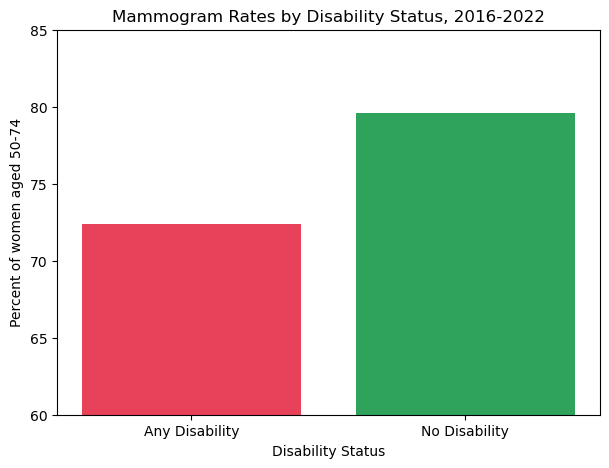

In [33]:
# Chart 1- average mammogram rates by disability status

# calculate average mammogram rate for each disability group
means = mammo.groupby('Stratification1')['Data_Value'].mean().round(1)

# set the chart size - width 7 inches, height 5 inches
plt.figure(figsize=(7, 5))

# draw the bar chart - x axis is group names, y axis is rates, two colors
plt.bar(means.index, means.values, color=['#E8425A', '#2FA35C'])

# add a title at the top
plt.title('Mammogram Rates by Disability Status, 2016-2022')

# label the x axis
plt.xlabel('Disability Status')

# label the y axis
plt.ylabel('Percent of women aged 50-74')

# set y axis to start at 60 and end at 85 so the gap is visible
plt.ylim(60, 85)

# save the chart as a PNG file to your folder
plt.savefig('chart1.png', dpi=150, bbox_inches='tight')

# display the chart in the notebook
plt.show()

# Remember T-X-Y

### Chart 2 — the spread

Your groupby gave you an *average*. But averages hide variation. Show the **distribution**
across states.


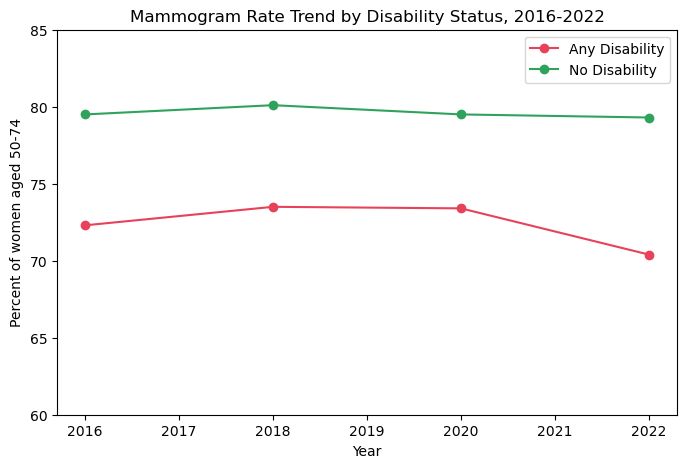

In [34]:
#Chart 2 - mammogram rate trend over time by disability status

#group by year AND disability status, calculate average, round to 1 decimal
#.unstack() pivots the disability groups into separate columns
#so each group becomes its own line on the chart

#group by year and disability status, average, then unstack into columns
trends = mammo.groupby(['Year', 'Stratification1'])['Data_Value'].mean().round(1).unstack()

#set chart size - width 8, height 5
plt.figure(figsize=(8, 5))

#draw the Any Disability line; marker='o' puts a dot at each data point; label= names it for the legend
plt.plot(trends.index, trends['Any Disability'], marker='o', label='Any Disability', color='#E8425A')

#draw the No Disability line - same structure, different color
plt.plot(trends.index, trends ['No Disability'], marker='o', label='No Disability', color= '#2FA35C')

#add title and labels
plt.title('Mammogram Rate Trend by Disability Status, 2016-2022')
plt.xlabel('Year')
plt.ylabel('Percent of women aged 50-74')
plt.legend()

#keep y axis same range as Chart 1 for consistency
plt.ylim(60, 85)

plt.savefig('chart2.png', dpi=150, bbox_inches='tight')

#display in notebook
plt.show()



### Chart 3 - comparing all three groups- No Disability, Hearing Disability and Any Disability



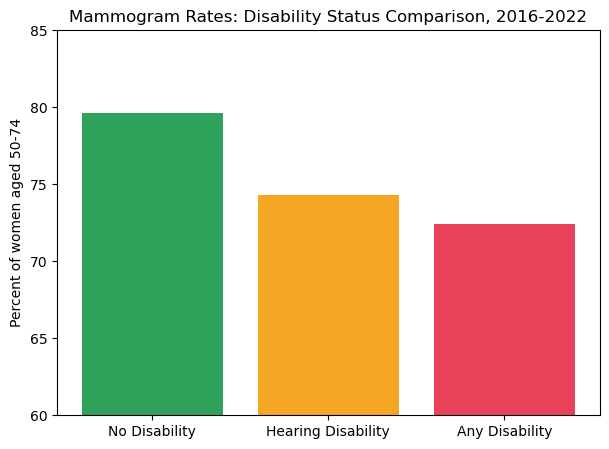

In [35]:
#Chart 3: comparing three groups: No Disability,  Hearing Disability, Any Disability

#create a dictionary: group names as keys, mammogram rates as values
#groups = {...} is a dictionary
groups= {
    'No Disability': 79.6, #name:value
    'Hearing Disability': 74.3, 
    'Any Disability': 72.4
}

#set chart size
plt.figure(figsize=(7, 5))

#draw bars - keys() gives the group names for x axis, values() gives the rates for bar height
#three colors - green, orange, red
plt.bar(groups.keys(), groups.values(), color=['#2FA35C', '#F5A623', '#E8425A'])

#add title
plt.title('Mammogram Rates: Disability Status Comparison, 2016-2022')

#label x axis
plt.xlabel('') #formerly had 'Group', but it bled into x-axis name

#label y axis
plt.ylabel('Percent of women aged 50-74')

#keep y axis same range as Charts 1 and 2 for consistency
plt.ylim(60, 85)

#save as PNG
plt.savefig('chart3.png', dpi=150, bbox_inches='tight')

#display in notebook
plt.show()

### Chart notes

- **Why I chose these chart types:** *I used bar charts for Charts 1 and because I am comparing categories: disability groups. I used a line chart for Chart 2 becasue I am showing change over time across four survey years. Chart type follows variable type*
  
- **What someone should see in 5 seconds:** *Chart 1: women with disabilities get few mammograms than women without. Chart 2: the gap was slowly closing, then widened sharply in 2022. Chart 3: Deaf and hard-of-hearing women fall in between which is better than the overall disability group but still behind women without disabilities.*


## 7. The story 

### My question

*Are women aged 50-74 with disabilities less likely to have had a mammogram in the past two years compared to women without disabilities, and is that gap wider for Deaf and hard-of-hearing (HoH) women?*

### What I did

*I used the CDC Disability and Health Data System (DHDS), a public dataset built from BRFF survey data collected from 2016-2022. I filtered tot he mammogram indicator, kept only Yes responses, and compared women with any disability to women without a disability. I then ran a sub-analysis on Hearing Disability specifically.*

### What I found

*Women with disabilities had a mammogram rate of 72.4%, compared to 79.6% for women without disabilities- a gap of 7.2 percentage points. The gap wideneed to 8.9 points in 2022, the largest gap in the dataset. Women with hearing disabilities had a rate of 74.3%, slightly better than the overall disability group but still 5.3 points below women without disabilities.*

### Why it matters

*Mammograms save lives only when women actually get them. A persistent gap in screening rates for women with disabilities mean delayed diagnosis and worse outcomes. The widening gap in 2022 suggests COVID-19 disproportionately disrupted screening access for this population. Health departments should target outreach specifically to women with disabilities, including accessible scheduling and communication accommodations for Deaf and HoH patients.*

*As a hard-of-hearing woman myself, with a MPH, this question is personally significant; communication barriers at healthcare facilities are real, and this data puts numbers to an experience many Deaf and HoH women share.*

### Limitations 

Candidates for this dataset:

- **Self-reported survey data** *The DHDS is built from BRFSS, a telephone survey. Women self-report whether they got a mammogram. People sometimes misremember or over-report health behaviors, which may affect accuracy. *
  
- **Confounding** *The analysis does not control for age, income, or income status. All three correlate with both disability status and mammogram rates. The gap may be partly explained by these factors rather than disability alone.*
- **Suppressed values** *The mammogram question was only asked in even years. The limits trend analysis only to four points in time.*
- **Coverage bias** *BRFSS is a telephone survey. People who cannot compplete a phone interview, including some Deaf individuals, may be underrepresented. This could mean the true gap for Deaf and HoH women is larger than reported. This is also true for hospitalization data, such as the discharge hospitalization data. Those figures could be be underreported and underrepresented by both the patient and provider.*
- **Coverage gap** *Disability status isn't collected on many other federal health datasets.*

### Source & citation

Centers for Disease Control and Prevention. Disability and Health Data System (DHDS).
Retrieved from data.cdc.gov, [date you downloaded it].

---